# RedRock Email Classification — Uncertainty & Routing

Quantifies prediction uncertainty (entropy/margin, and a conformal prediction proof-of-concept via MAPIE), then decides an auto-forward vs. defer-to-human routing threshold. Logic lives in `src/uncertainty.py`.

In [17]:
import sys
sys.path.append("..")
from pathlib import Path
import numpy as np
import pandas as pd
import importlib
from sklearn.svm import LinearSVC
from src.calibration import build_calibrated_pipeline

import src.ingestion, src.preprocessing, src.features, src.modelling, src.uncertainty
importlib.reload(sys.modules['src.ingestion'])
importlib.reload(sys.modules['src.preprocessing'])
importlib.reload(sys.modules['src.features'])
importlib.reload(sys.modules['src.modelling'])
importlib.reload(sys.modules['src.uncertainty'])
importlib.reload(src.ingestion)
importlib.reload(src.preprocessing)
importlib.reload(src.features)
importlib.reload(src.modelling)
importlib.reload(src.uncertainty)

from src.ingestion import build_dataframe, load_labels
from src.preprocessing import add_clean_text_column
from src.features import add_engineered_features
from src.modelling import STRUCTURED_BOOL_COLS, STRUCTURED_NUM_COLS, build_text_pipeline
from src.uncertainty import (calculate_heuristic_uncertainty, build_conformal_router,
                              execute_routing_decision, select_operating_threshold,
                              save_routing_results)

## 1. Load data and the calibrated model

In [18]:
import pickle, json
from sklearn.model_selection import StratifiedKFold, cross_val_predict

BASE_DIR = Path(r"C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier")
TRAIN_DIR, LABELS_PATH = BASE_DIR / "train", BASE_DIR / "train_labels.csv"
MODELS_DIR = BASE_DIR / "outputs" / "models"

train_df = build_dataframe(TRAIN_DIR)
labels_df = load_labels(LABELS_PATH)
train_labeled = train_df.merge(labels_df, left_on="source_filename", right_on="filename", how="left")
train_labeled = add_clean_text_column(train_labeled)
train_labeled = add_engineered_features(train_labeled)

y = train_labeled["true_category"]
X = train_labeled[["subject", "message"] + STRUCTURED_BOOL_COLS + STRUCTURED_NUM_COLS]

with open(MODELS_DIR / "best_model_calibrated.pkl", "rb") as f:
    calibrated_pipeline = pickle.load(f)
with open(MODELS_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

print(f"Loaded {metadata['model_type']}, calibration improvement: "
      f"{metadata['average_brier_improvement']:.1f}%")

Loaded LinearSVC, calibration improvement: 26.1%


## 2. Heuristic uncertainty (entropy & margin)

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
calib_proba = cross_val_predict(calibrated_pipeline, X, y, cv=skf, method="predict_proba")

entropies, margins = calculate_heuristic_uncertainty(calib_proba)
print(f"Entropy - mean: {entropies.mean():.3f} bits (max possible: {np.log2(5):.3f})")
print(f"Margin  - mean: {margins.mean():.3f}")

Entropy - mean: 1.533 bits (max possible: 2.322)
Margin  - mean: 0.480


## 3. Conformal prediction proof-of-concept (MAPIE)

**Limitation, stated plainly**: the calibration set carved out here is ~25% of 44 examples (~11 emails). MAPIE's marginal coverage guarantee is a large-sample-asymptotic result; at this scale the guarantee is demonstrative, not statistically reliable. Included to show the method, not as a production-grade result.

In [20]:

base_pipeline = build_calibrated_pipeline(
    LinearSVC(class_weight="balanced", random_state=42),
    ("subject", "message"),
    cv=3   
)

mapie_clf = build_conformal_router(base_pipeline, X, y, test_size=0.25, confidence_level=0.9, random_state=42)
routing_mapie = execute_routing_decision(mapie_clf, X)

n_auto_mapie = sum(1 for r in routing_mapie if r.startswith("AUTO_FORWARD"))
print(f"MAPIE conformal (90% target coverage): {n_auto_mapie}/{len(routing_mapie)} auto-forward")

MAPIE conformal (90% target coverage): 44/44 auto-forward


## 4. Confidence-threshold routing (primary approach used for `outputs/results.csv`)

**Limitation, stated plainly**: the threshold below is selected and evaluated on the same cross-validated predictions -- optimistic by construction. Should be re-validated on a genuinely held-out set before production use.

In [21]:
class_names = calibrated_pipeline.classes_
selected_threshold, metrics_df, routing_df = select_operating_threshold(
    calib_proba, y.values, class_names
)
print(f"Selected threshold: {selected_threshold:.3f}")
print(routing_df["decision"].value_counts())

Selected threshold: 0.575
decision
AUTO_FORWARD      33
DEFER_TO_HUMAN    11
Name: count, dtype: int64


## 5. Save routing results

In [22]:
auto, defer = save_routing_results(routing_df, selected_threshold, MODELS_DIR, metadata)
print(f"Auto-forward: {auto} ({auto/(auto+defer)*100:.1f}%)")
print(f"Defer to human: {defer} ({defer/(auto+defer)*100:.1f}%)")

Auto-forward: 33 (75.0%)
Defer to human: 11 (25.0%)


## 6. Evaluate routing decisions: was AUTO_FORWARD actually correct?

So far we know *how many* emails were auto-forwarded vs deferred, but not whether the auto-forwarded ones were classified correctly. This checks it directly against `true_category`.

In [23]:
routing_eval = pd.DataFrame({
    "email_id": train_labeled["email_id"].values,
    "true_category": y.values,
    "predicted": routing_df["predicted_class"].values,
    "confidence": routing_df["confidence"].values,
    "decision": routing_df["decision"].values,
    "margin": margins,
    "entropy": entropies,
})
routing_eval["correct"] = routing_eval["true_category"] == routing_eval["predicted"]

auto_group = routing_eval[routing_eval["decision"] == "AUTO_FORWARD"]
deferred_group = routing_eval[routing_eval["decision"] == "DEFER_TO_HUMAN"]

auto_acc = auto_group["correct"].mean() * 100
deferred_acc = deferred_group["correct"].mean() * 100

print(f"AUTO_FORWARD ({len(auto_group)} emails) -- accuracy: {auto_acc:.1f}%")
print(f"DEFER_TO_HUMAN ({len(deferred_group)} emails) -- accuracy if auto-routed anyway: {deferred_acc:.1f}%")

if auto_group["correct"].mean() == 1.0:
    print("Threshold design confirmed: zero errors among auto-forwarded emails.")
else:
    print("WARNING: errors found among auto-forwarded emails -- investigate threshold.")


AUTO_FORWARD (33 emails) -- accuracy: 100.0%
DEFER_TO_HUMAN (11 emails) -- accuracy if auto-routed anyway: 72.7%
Threshold design confirmed: zero errors among auto-forwarded emails.


## 7. Confusion matrix — deferred emails only

Shows concretely *where* the model is genuinely unsure, restricted to the emails that were not auto-forwarded.

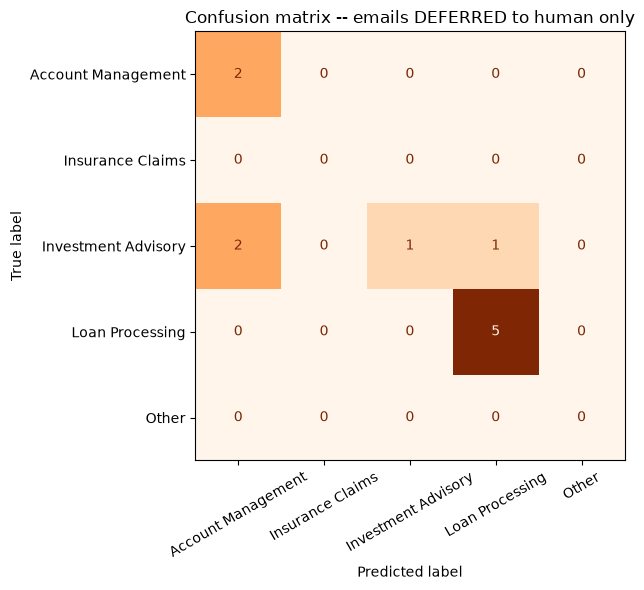

                     precision    recall  f1-score   support

 Account Management       0.50      1.00      0.67         2
   Insurance Claims       0.00      0.00      0.00         0
Investment Advisory       1.00      0.25      0.40         4
    Loan Processing       0.83      1.00      0.91         5
              Other       0.00      0.00      0.00         0

           accuracy                           0.73        11
          macro avg       0.47      0.45      0.40        11
       weighted avg       0.83      0.73      0.68        11



In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

class_names = sorted(y.unique())
cm_deferred = confusion_matrix(deferred_group["true_category"], deferred_group["predicted"],
                                 labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_deferred, display_labels=class_names).plot(
    ax=ax, cmap="Oranges", xticks_rotation=30, colorbar=False)
ax.set_title("Confusion matrix -- emails DEFERRED to human only")
plt.tight_layout()
plt.show()

print(classification_report(deferred_group["true_category"], deferred_group["predicted"],
                              labels=class_names, zero_division=0))

## 8. Deferred count by true category

If deferrals concentrate on the smallest classes (fewer training examples), that is consistent with everything already established: less training signal legitimately means more uncertainty, not a hidden flaw.

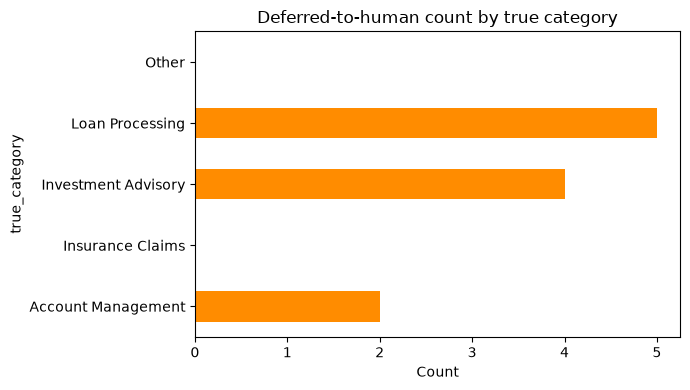

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
deferred_group["true_category"].value_counts().reindex(class_names, fill_value=0).plot(
    kind="barh", ax=ax, color="darkorange")
ax.set_title("Deferred-to-human count by true category")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

## 9. Explainability for deferred emails (SHAP)

For each deferred email, extracts the top contributing words/features so the deferral can be justified concretely in a presentation or audit -- e.g. \"this email had a 0.08 margin between Insurance Claims and Loan Processing, with 'policy' and 'payment' pulling in opposite directions\" rather than a vague \"the model was unsure\".

In [26]:
import importlib
import src.explainability
importlib.reload(src.explainability)
from src.explainability import initialize_shap_explainer, generate_compliance_audit_trail

explainer, shap_values, feature_names = initialize_shap_explainer(calibrated_pipeline, X)

deferred_indices = routing_eval[routing_eval["decision"] == "DEFER_TO_HUMAN"].index.tolist()
X_deferred = X.loc[deferred_indices]

audit_deferred = generate_compliance_audit_trail(calibrated_pipeline, X_deferred, top_n=5)
audit_deferred["email_id"] = train_labeled.loc[deferred_indices, "email_id"].values
audit_deferred["true_category"] = y.loc[deferred_indices].values
audit_deferred["margin"] = routing_eval.loc[deferred_indices, "margin"].values
audit_deferred["entropy"] = routing_eval.loc[deferred_indices, "entropy"].values

audit_deferred[["email_id", "true_category", "predicted_category", "margin", "entropy", "top_driving_features"]]

,email_id,true_category,predicted_category,margin,entropy,top_driving_features
0,43,Account Management,Account Management,0.226020,1.739618,setup (0.12) | online (0.09) | banking (0.09) ...
1,27,Investment Advisory,Investment Advisory,0.200074,1.917112,risk (0.12) | assessment (0.12) | bool_feature...
2,13,Loan Processing,Loan Processing,0.099253,1.871057,loan (0.26) | business (0.18) | bool_features_...
3,33,Loan Processing,Loan Processing,0.238007,1.785562,loan (0.22) | refinancing (0.14) | student (0....
4,46,Investment Advisory,Investment Advisory,0.023153,1.960594,dividend (0.10) | plan (0.10) | reinvestment (...
5,12,Investment Advisory,Investment Advisory,0.418854,1.796030,market (0.21) | analysis (0.16) | bool_feature...
6,3,Loan Processing,Loan Processing,0.124880,2.042236,application (0.14) | mortgage (0.12) | status ...
7,28,Loan Processing,Loan Processing,0.128500,1.897207,application (0.14) | credit (0.13) | card (0.1...
8,38,Loan Processing,Loan Processing,0.133781,1.867804,loan (0.23) | business (0.16) | small (0.12) |...
9,6,Account Management,Account Management,0.385459,1.771798,request (0.16) | password (0.09) | reset (0.09...


## 10. Save the deferred-email audit trail

In [27]:
audit_deferred.to_csv(MODELS_DIR / "deferred_audit_trail.csv", index=False)
print(f"Saved {len(audit_deferred)} deferred-email explanations to deferred_audit_trail.csv")

Saved 11 deferred-email explanations to deferred_audit_trail.csv


## 11. Plot: margin & entropy per deferred email

Sorted by margin (ascending) -- the most ambiguous email appears first. Quick visual read of *how* uncertain each deferred case is, rather than reading numbers row by row.

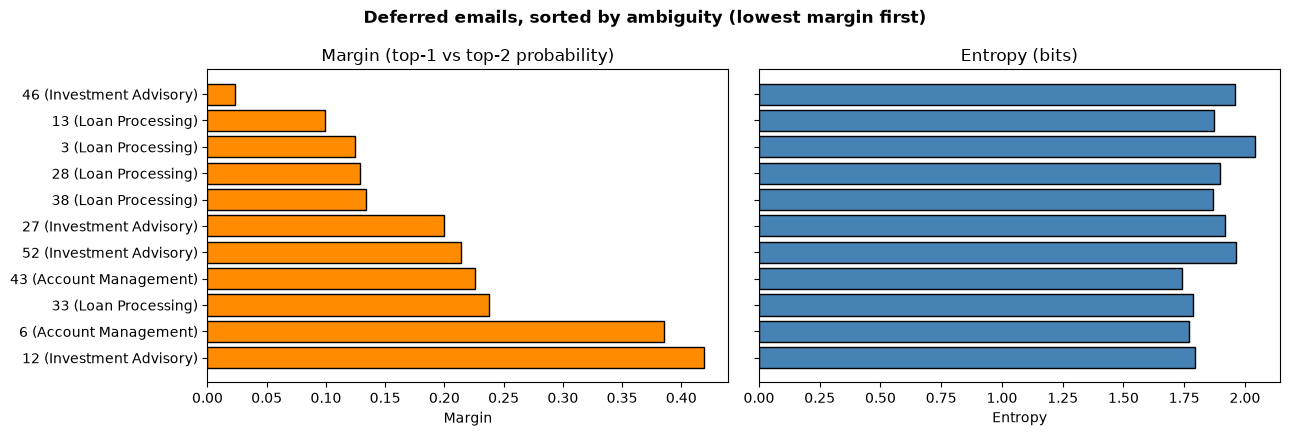

In [28]:
import matplotlib.pyplot as plt

plot_df = audit_deferred.sort_values("margin").reset_index(drop=True)
labels = plot_df["email_id"].astype(str) + " (" + plot_df["true_category"] + ")"

fig, axes = plt.subplots(1, 2, figsize=(13, max(3, len(plot_df) * 0.4)))

axes[0].barh(labels, plot_df["margin"], color="darkorange", edgecolor="black")
axes[0].set_title("Margin (top-1 vs top-2 probability)")
axes[0].set_xlabel("Margin")
axes[0].invert_yaxis()

axes[1].barh(labels, plot_df["entropy"], color="steelblue", edgecolor="black")
axes[1].set_title("Entropy (bits)")
axes[1].set_xlabel("Entropy")
axes[1].invert_yaxis()
axes[1].set_yticklabels([])

plt.suptitle("Deferred emails, sorted by ambiguity (lowest margin first)", fontweight="bold")
plt.tight_layout()
plt.show()

## 12. SHAP waterfall — the single most ambiguous deferred email

Shows step-by-step how each word/feature pushed the prediction towards its predicted class, for the case where the model was least confident. This is the concrete example to walk through in a presentation when justifying a deferral.

Most ambiguous deferred email: 46 (true category: Investment Advisory, margin: 0.023)


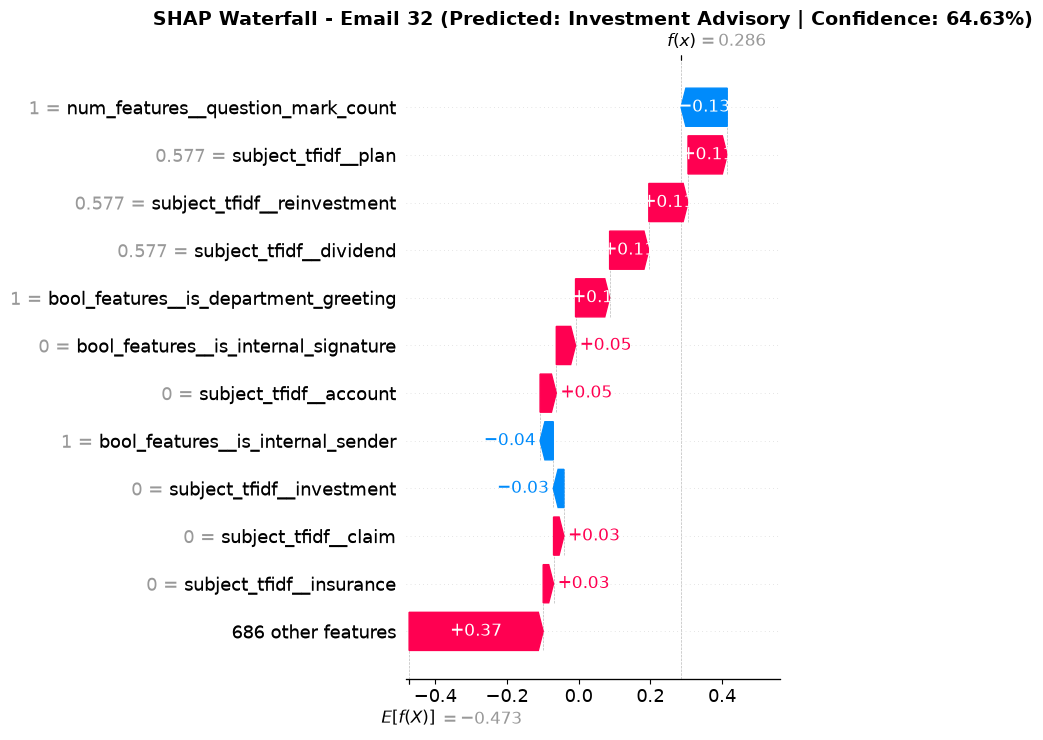

Waterfall plot generated: shows top 12 features contributing to predicting 'Investment Advisory'


In [29]:
from src.explainability import plot_waterfall

most_ambiguous_idx = audit_deferred.sort_values("margin").iloc[0]["email_id"]
# map back to a positional index in X for plot_waterfall
row_label = train_labeled.index[train_labeled["email_id"] == most_ambiguous_idx][0]
sample_pos = X.index.get_loc(row_label)

print(f"Most ambiguous deferred email: {most_ambiguous_idx} "
      f"(true category: {y.loc[row_label]}, margin: {margins[sample_pos]:.3f})")

plot_waterfall(calibrated_pipeline, X, explainer, shap_values, feature_names,
               sample_idx=sample_pos, max_display=12)

## 13. Feature importance restricted to deferred emails only

Global feature importance (computed earlier) reflects the whole dataset. This restricts the same calculation to only the deferred subset, to see whether different words/features drive ambiguity specifically -- useful to check whether deferrals share a common cause (e.g. one feature systematically absent) rather than being scattered.

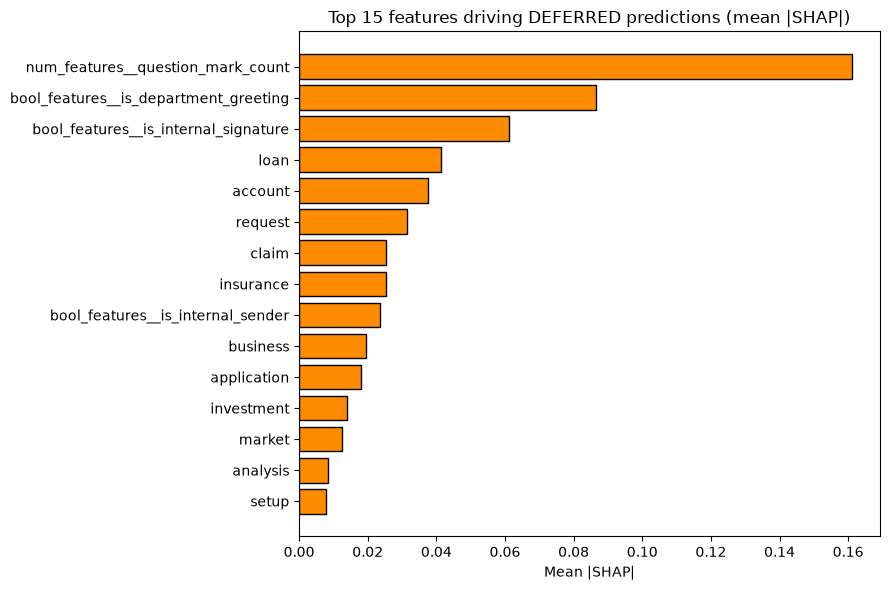

In [30]:
import numpy as np

deferred_positions = [X.index.get_loc(idx) for idx in deferred_indices]
deferred_shap = shap_values.values[deferred_positions, :, :]

deferred_importance = np.mean(np.abs(deferred_shap), axis=(0, 2))
top_n = 15
top_idx = np.argsort(-deferred_importance)[:top_n]

clean_names = [feature_names[i].replace("subject_tfidf__", "").replace("body_tfidf__", "")
               for i in top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(clean_names, deferred_importance[top_idx], color="darkorange", edgecolor="black")
ax.set_title(f"Top {top_n} features driving DEFERRED predictions (mean |SHAP|)")
ax.set_xlabel("Mean |SHAP|")
ax.invert_yaxis()
plt.tight_layout()
plt.show()